optimizer：Adam

总参数量: 4929


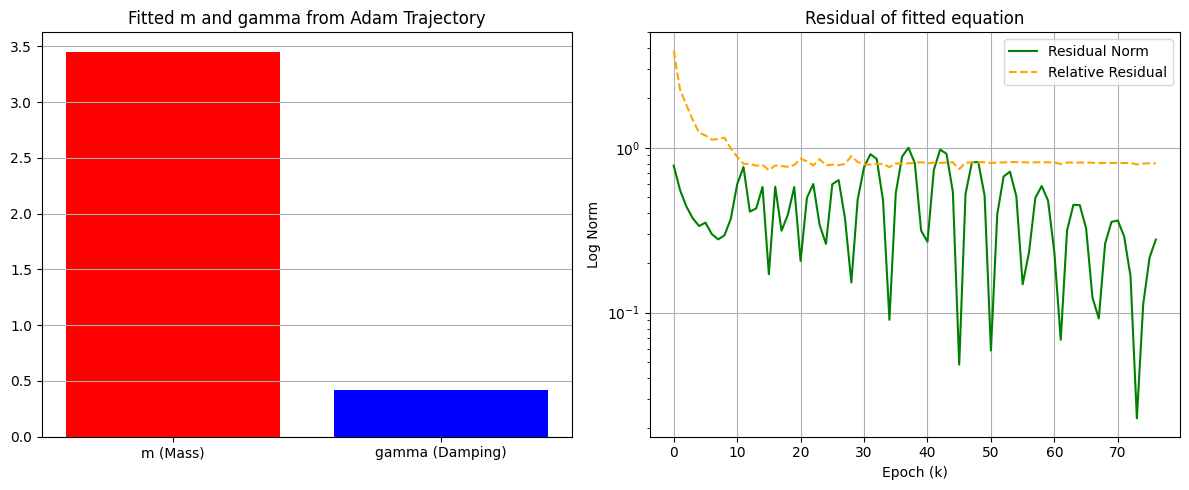


拟合结果 (梯度对齐到 L_80)：
  m     = 3.453720
  gamma = 0.419191
 残差范数平均值: 0.444648
 相对残差平均值: 0.911658
 拟合残差平方和: 19.754084

❌ 相对残差较大，说明该方程或对齐方式不适用。


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 构建小型神经网络 Input -> 64 -> 64 -> Output
# ==========================================
class SimpleNet(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=1):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ==========================================
# 2. 生成数据和初始化
# ==========================================
input_dim = 10
output_dim = 1
X = torch.randn(200, input_dim)
y = torch.randn(200, output_dim)

model = SimpleNet()
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ==========================================
# 3. 收集训练轨迹 (theta, grad)
# ==========================================
theta_history = []  # 存储每一轮的展平参数
grad_history = []   # 存储每一轮的负梯度 (-∇L)

epochs = 80
model.train()

for k in range(epochs):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()

    # 收集当前参数 θ_k (展平成一维向量)
    current_theta = torch.cat([p.data.view(-1) for p in model.parameters()])
    theta_history.append(current_theta.cpu().numpy())

    # 收集负梯度 -∇L_k
    current_grad = torch.cat([p.grad.view(-1) for p in model.parameters()])
    grad_history.append(-current_grad.cpu().numpy())

    optimizer.step()

theta_traj = np.array(theta_history)
grad_traj = np.array(grad_history)

print(f"总参数量: {theta_traj.shape[1]}")

# ==========================================
# 4. 计算速度和加速度
# ==========================================
# 速度 v_k = θ_{k+1} - θ_k
v_traj = np.diff(theta_traj, axis=0)

# 加速度 a_k = v_{k+1} - v_k
a_traj = np.diff(v_traj, axis=0)

# ==========================================
# 5. 对齐梯度到 L_{k+1}（核心修改）
# ==========================================
# 原代码中 grad_traj 存的是 -∇L(θ_k)
# 现在明确对齐到 θ_{k+1}，即使用 L_{k+1} 的梯度
aligned_v_traj = v_traj[1:-1]        # (epochs-3, total_params)
aligned_a_traj = a_traj[1:]          # (epochs-3, total_params)
aligned_grad_traj = grad_traj[2:-1]  # (epochs-3, total_params)

# ==========================================
# 6. 最小二乘法拟合 m 和 gamma
# ==========================================
X_data = np.column_stack((aligned_a_traj.ravel(), aligned_v_traj.ravel()))
Y_data = aligned_grad_traj.ravel()

res = np.linalg.lstsq(X_data, Y_data, rcond=None)
m_fitted, gamma_fitted = res[0]
fitting_residual_sum = res[1][0] if len(res[1]) > 0 else 0

# ==========================================
# 7. 计算残差
# ==========================================
Y_pred = m_fitted * aligned_a_traj + gamma_fitted * aligned_v_traj
residuals = np.linalg.norm(Y_pred + (-aligned_grad_traj), axis=1)

grad_norms = np.linalg.norm(aligned_grad_traj, axis=1)
relative_residuals = np.where(grad_norms > 1e-12, residuals / grad_norms, 0)

# ==========================================
# 8. 可视化
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['m (Mass)', 'gamma (Damping)'], [m_fitted, gamma_fitted], color=['red', 'blue'])
plt.title('Fitted m and gamma from Adam Trajectory')
plt.grid(axis='y')

plt.subplot(1, 2, 2)
plt.plot(residuals, label='Residual Norm', color='green')
plt.plot(relative_residuals, label='Relative Residual', color='orange', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch (k)')
plt.ylabel('Log Norm')
plt.title('Residual of fitted equation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 9. 输出结果
# ==========================================
print(f"\n{'='*40}")
print(f"拟合结果 (梯度对齐到 L_{k+1})：")
print(f"  m     = {m_fitted:.6f}")
print(f"  gamma = {gamma_fitted:.6f}")
print(f" 残差范数平均值: {np.mean(residuals):.6f}")
print(f" 相对残差平均值: {np.mean(relative_residuals):.6f}")
print(f" 拟合残差平方和: {fitting_residual_sum:.6f}")
print(f"{'='*40}")

if np.mean(relative_residuals) < 0.1:
    print("\n✅ 相对残差较小 (<10%)，说明 Adam 轨迹在 L_{k+1} 处与该牛顿方程非常吻合。")
elif np.mean(relative_residuals) < 0.5:
    print("\n⚠️ 相对残差适中，说明轨迹部分遵循物理规律，但存在显著偏差。")
else:
    print("\n❌ 相对残差较大，说明该方程或对齐方式不适用。")

momentum SGD

总参数量: 4929
aligned_v_traj shape: (77, 4929)
aligned_a_traj shape: (77, 4929)
aligned_grad_traj shape: (77, 4929)


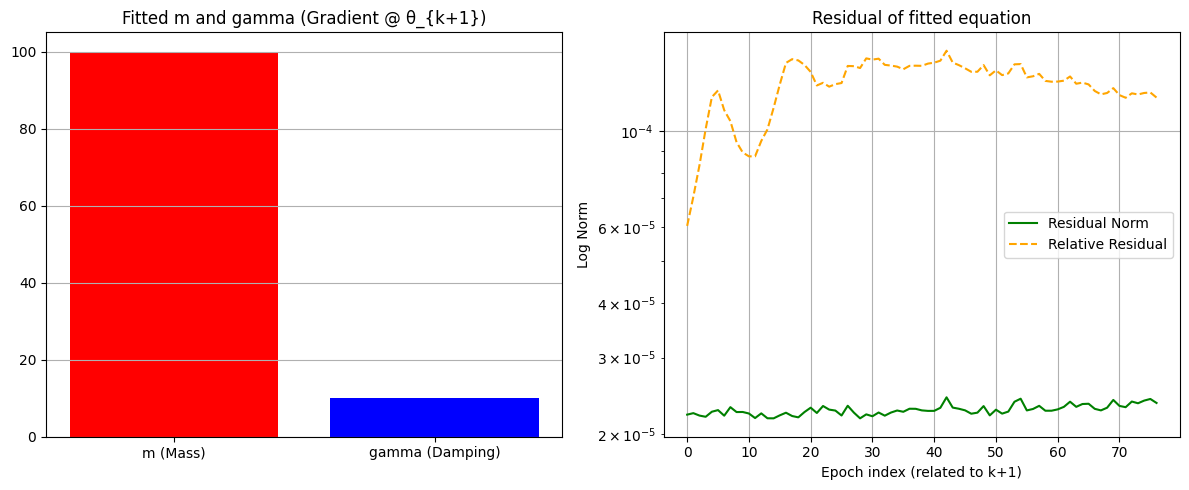


拟合结果 (梯度在 θ_80)：
  m     = 100.000008
  gamma = 10.000004
 残差范数平均值: 0.000023
 相对残差平均值: 0.000128
 拟合残差平方和: 0.000000

✅ 相对残差很小 (<10%)。这说明 Momentum SGD 的轨迹在 θ_{k+1} 处与该牛顿方程非常吻合。


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 构建小型神经网络 Input -> 64 -> 64 -> Output
# ==========================================
class SimpleNet(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=1):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ==========================================
# 2. 生成数据和初始化
# ==========================================
input_dim = 10
output_dim = 1
X = torch.randn(200, input_dim)
y = torch.randn(200, output_dim)

model = SimpleNet()
loss_fn = nn.MSELoss()

# 使用 Momentum SGD
learning_rate = 0.01
momentum = 0.9
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

# ==========================================
# 3. 收集训练轨迹 (theta, grad)
# ==========================================
theta_history = []
grad_history = []

epochs = 80
model.train()

for k in range(epochs):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()

    # 收集当前参数 θ_k
    current_theta = torch.cat([p.data.view(-1) for p in model.parameters()])
    theta_history.append(current_theta.cpu().numpy())

    # 收集 -∇L(θ_k)
    current_grad = torch.cat([p.grad.view(-1) for p in model.parameters()])
    grad_history.append(-current_grad.cpu().numpy())

    optimizer.step()  # 更新到 θ_{k+1}

theta_traj = np.array(theta_history)
grad_traj = np.array(grad_history)

print(f"总参数量: {theta_traj.shape[1]}")

# ==========================================
# 4. 计算速度与加速度
# ==========================================
# v_k = θ_{k+1} - θ_k
v_traj = np.diff(theta_traj, axis=0)  # (epochs-1, total_params)

# a_k = v_{k+1} - v_k = (θ_{k+2} - θ_{k+1}) - (θ_{k+1} - θ_k)
a_traj = np.diff(v_traj, axis=0)      # (epochs-2, total_params)

# ==========================================
# 5. 参数对齐（核心修改）
# ==========================================
# 我们想让方程在 θ_{k+1} 的位置成立：
# m * a_k + gamma * v_k = -∇L(θ_{k+1})
# 所以需要让 v_k, a_k 和 grad_{k+1} 对齐

# 对齐方式：
aligned_v_traj = v_traj[1:-1]         # (epochs-3, total_params)
aligned_a_traj = a_traj[1:]           # (epochs-3, total_params)
aligned_grad_traj = grad_traj[2:-1]   # (epochs-3, total_params)

# 验证一下尺寸是否一致
print(f"aligned_v_traj shape: {aligned_v_traj.shape}")
print(f"aligned_a_traj shape: {aligned_a_traj.shape}")
print(f"aligned_grad_traj shape: {aligned_grad_traj.shape}")

# ==========================================
# 6. 最小二乘法拟合 m 和 gamma
# ==========================================
X_data = np.column_stack((aligned_a_traj.ravel(), aligned_v_traj.ravel()))
Y_data = aligned_grad_traj.ravel()

res = np.linalg.lstsq(X_data, Y_data, rcond=None)
m_fitted, gamma_fitted = res[0]
fitting_residual_sum = res[1][0] if len(res[1]) > 0 else 0

# ==========================================
# 7. 计算残差
# ==========================================
Y_pred = m_fitted * aligned_a_traj + gamma_fitted * aligned_v_traj
residuals = np.linalg.norm(Y_pred - aligned_grad_traj, axis=1)  # 因为 aligned_grad_traj 是 -∇L

grad_norms = np.linalg.norm(aligned_grad_traj, axis=1)
relative_residuals = np.where(grad_norms > 1e-12, residuals / grad_norms, 0)

# ==========================================
# 8. 可视化
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['m (Mass)', 'gamma (Damping)'], [m_fitted, gamma_fitted], color=['red', 'blue'])
plt.title('Fitted m and gamma (Gradient @ θ_{k+1})')
plt.grid(axis='y')

plt.subplot(1, 2, 2)
plt.plot(residuals, label='Residual Norm', color='green')
plt.plot(relative_residuals, label='Relative Residual', color='orange', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch index (related to k+1)')
plt.ylabel('Log Norm')
plt.title('Residual of fitted equation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 9. 结果输出
# ==========================================
print(f"\n{'='*40}")
print(f"拟合结果 (梯度在 θ_{k+1})：")
print(f"  m     = {m_fitted:.6f}")
print(f"  gamma = {gamma_fitted:.6f}")
print(f" 残差范数平均值: {np.mean(residuals):.6f}")
print(f" 相对残差平均值: {np.mean(relative_residuals):.6f}")
print(f" 拟合残差平方和: {fitting_residual_sum:.6f}")
print(f"{'='*40}")

if np.mean(relative_residuals) < 0.1:
    print("\n✅ 相对残差很小 (<10%)。这说明 Momentum SGD 的轨迹在 θ_{k+1} 处与该牛顿方程非常吻合。")
else:
    print("\n❌ 相对残差较大，说明该方程或对齐方式不适用。")

SGD

总参数量: 4929
aligned_v_traj shape: (77, 4929)
aligned_a_traj shape: (77, 4929)
aligned_grad_traj shape: (77, 4929)


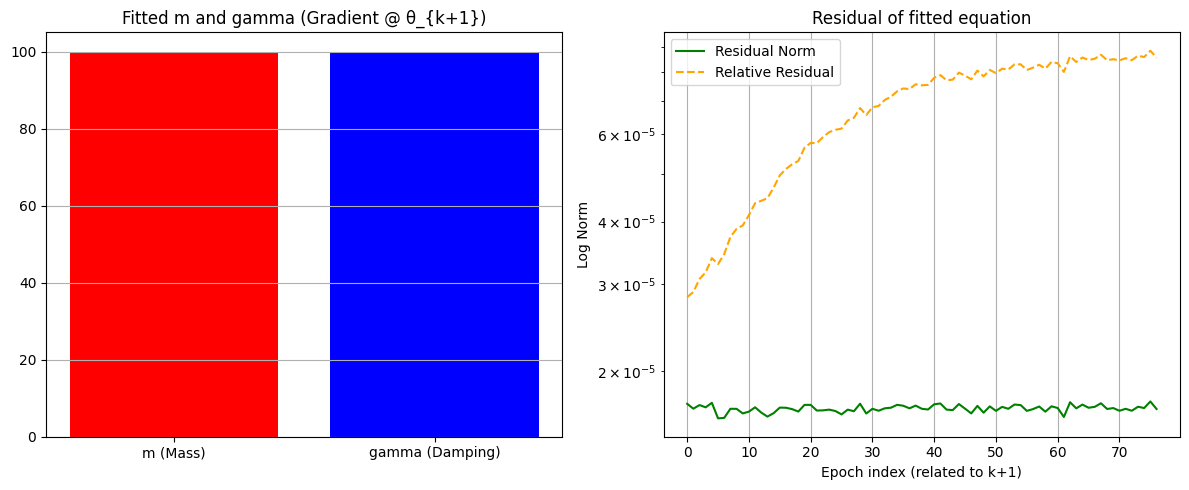


拟合结果 (梯度在 θ_80)：
  m     = 99.999908
  gamma = 100.000000
 残差范数平均值: 0.000017
 相对残差平均值: 0.000068
 拟合残差平方和: 0.000000

✅ 相对残差很小 (<10%)。这说明SGD 的轨迹在 θ_{k+1} 处与该牛顿方程非常吻合。


In [ ]:
 #pytorch

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 构建小型神经网络 Input -> 64 -> 64 -> Output
# ==========================================
class SimpleNet(nn.Module):
    def __init__(self, input_dim=10, hidden_dim=64, output_dim=1):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ==========================================
# 2. 生成数据和初始化
# ==========================================
input_dim = 10
output_dim = 1
X = torch.randn(200, input_dim)
y = torch.randn(200, output_dim)

model = SimpleNet()
loss_fn = nn.MSELoss()

# 使用 Momentum SGD
optimizer = optim.SGD(model.parameters(), lr=0.01)

# ==========================================
# 3. 收集训练轨迹 (theta, grad)
# ==========================================
theta_history = []
grad_history = []

epochs = 80
model.train()

for k in range(epochs):
    optimizer.zero_grad()
    pred = model(X)
    loss = loss_fn(pred, y)
    loss.backward()

    # 收集当前参数 θ_k
    current_theta = torch.cat([p.data.view(-1) for p in model.parameters()])
    theta_history.append(current_theta.cpu().numpy())

    # 收集 -∇L(θ_k)
    current_grad = torch.cat([p.grad.view(-1) for p in model.parameters()])
    grad_history.append(-current_grad.cpu().numpy())

    optimizer.step()  # 更新到 θ_{k+1}

theta_traj = np.array(theta_history)
grad_traj = np.array(grad_history)

print(f"总参数量: {theta_traj.shape[1]}")

# ==========================================
# 4. 计算速度与加速度
# ==========================================
# v_k = θ_{k+1} - θ_k
v_traj = np.diff(theta_traj, axis=0)  # (epochs-1, total_params)

# a_k = v_{k+1} - v_k = (θ_{k+2} - θ_{k+1}) - (θ_{k+1} - θ_k)
a_traj = np.diff(v_traj, axis=0)      # (epochs-2, total_params)

# ==========================================
# 5. 参数对齐（核心修改）
# ==========================================
# 我们想让方程在 θ_{k+1} 的位置成立：
# m * a_k + gamma * v_k = -∇L(θ_{k+1})
# 所以需要让 v_k, a_k 和 grad_{k+1} 对齐

# 对齐方式：
aligned_v_traj = v_traj[1:-1]         # (epochs-3, total_params)
aligned_a_traj = a_traj[1:]           # (epochs-3, total_params)
aligned_grad_traj = grad_traj[2:-1]   # (epochs-3, total_params)

# 验证一下尺寸是否一致
print(f"aligned_v_traj shape: {aligned_v_traj.shape}")
print(f"aligned_a_traj shape: {aligned_a_traj.shape}")
print(f"aligned_grad_traj shape: {aligned_grad_traj.shape}")

# ==========================================
# 6. 最小二乘法拟合 m 和 gamma
# ==========================================
X_data = np.column_stack((aligned_a_traj.ravel(), aligned_v_traj.ravel()))
Y_data = aligned_grad_traj.ravel()

res = np.linalg.lstsq(X_data, Y_data, rcond=None)
m_fitted, gamma_fitted = res[0]
fitting_residual_sum = res[1][0] if len(res[1]) > 0 else 0

# ==========================================
# 7. 计算残差
# ==========================================
Y_pred = m_fitted * aligned_a_traj + gamma_fitted * aligned_v_traj
residuals = np.linalg.norm(Y_pred - aligned_grad_traj, axis=1)  # 因为 aligned_grad_traj 是 -∇L

grad_norms = np.linalg.norm(aligned_grad_traj, axis=1)
relative_residuals = np.where(grad_norms > 1e-12, residuals / grad_norms, 0)

# ==========================================
# 8. 可视化
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(['m (Mass)', 'gamma (Damping)'], [m_fitted, gamma_fitted], color=['red', 'blue'])
plt.title('Fitted m and gamma (Gradient @ θ_{k+1})')
plt.grid(axis='y')

plt.subplot(1, 2, 2)
plt.plot(residuals, label='Residual Norm', color='green')
plt.plot(relative_residuals, label='Relative Residual', color='orange', linestyle='--')
plt.yscale('log')
plt.xlabel('Epoch index (related to k+1)')
plt.ylabel('Log Norm')
plt.title('Residual of fitted equation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ==========================================
# 9. 结果输出
# ==========================================
print(f"\n{'='*40}")
print(f"拟合结果 (梯度在 θ_{k+1})：")
print(f"  m     = {m_fitted:.6f}")
print(f"  gamma = {gamma_fitted:.6f}")
print(f" 残差范数平均值: {np.mean(residuals):.6f}")
print(f" 相对残差平均值: {np.mean(relative_residuals):.6f}")
print(f" 拟合残差平方和: {fitting_residual_sum:.6f}")
print(f"{'='*40}")

if np.mean(relative_residuals) < 0.1:
    print("\n✅ 相对残差很小 (<10%)。这说明SGD 的轨迹在 θ_{k+1} 处与该牛顿方程非常吻合。")
else:
    print("\n❌ 相对残差较大，说明该方程或对齐方式不适用。")